[NAIVE] Mean CI coverage: 0.934
[MODIFIED] Mean CI coverage: 0.934
[WILD] Mean CI coverage: 0.934
[BLOCK] Mean CI coverage: 0.934
[NAIVE] Mean CI length: 0.359
[MODIFIED] Mean CI length: 0.362
[WILD] Mean CI length: 0.355
[BLOCK] Mean CI length: 0.362


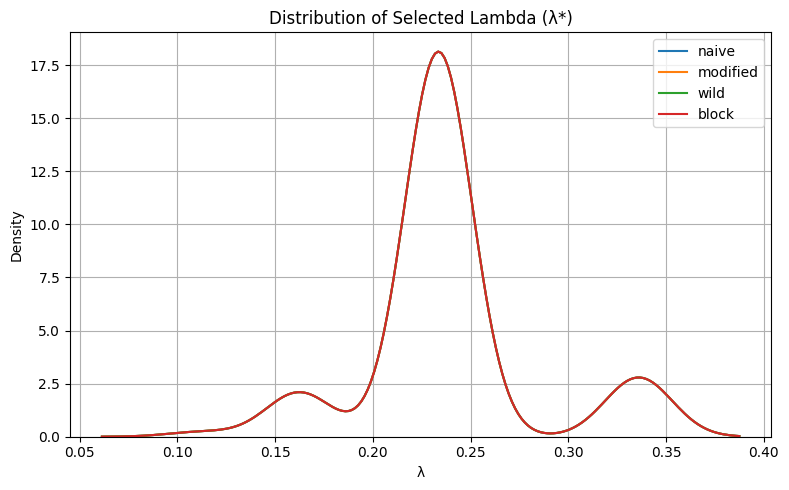

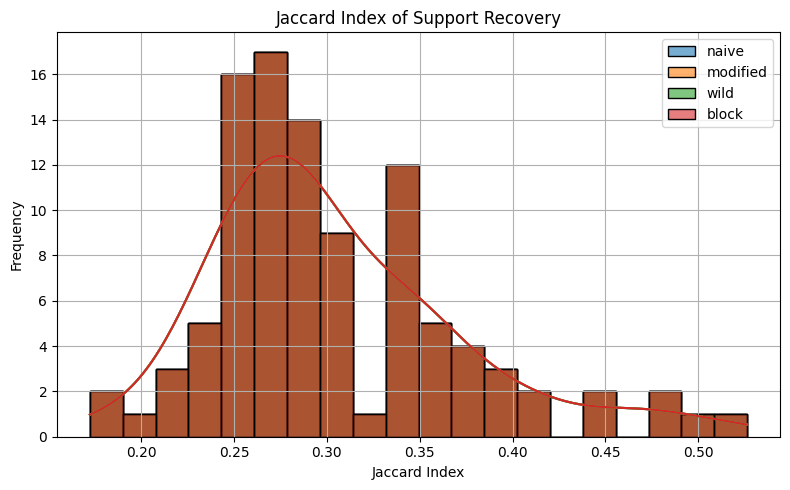

In [ ]:
import numpy as np
from simulation import Simulation  # assuming your simulation class is saved there
import matplotlib.pyplot as plt
import seaborn as sns

# Simulation setup (Case I)
n = 200                  # sample size
p = 100                  # number of predictors
s = 10                   # number of active coefficients
R = 100                  # Monte Carlo repetitions
B = 100                  # bootstrap replicates per method
signal_type = "strong"   # signal structure
error_type = "heteroskedastic"  # error structure (Case I)
a_n = 0.05               # thresholding parameter
lambdas = np.logspace(-3, 0, 20)  # λ grid
block_length = None      # block length auto-determined

# Run the simulation
study = Simulation(n, p, s, R, B, signal_type, error_type, lambdas, a_n, block_length)
results = study.run()

# --- Example output analysis ---

# 1. CI coverage (mean across β)
for method in results:
    mean_coverage = results[method]['coverage'].mean(axis=0).mean()
    print(f"[{method.upper()}] Mean CI coverage: {mean_coverage:.3f}")

# 2. CI length
for method in results:
    mean_length = results[method]['ci_length'].mean(axis=0).mean()
    print(f"[{method.upper()}] Mean CI length: {mean_length:.3f}")

# 3. Lambda distribution
plt.figure(figsize=(8, 5))
for method in results:
    sns.kdeplot(results[method]['lambda_star'], label=method)
plt.title("Distribution of Selected Lambda (λ*)")
plt.xlabel("λ")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Jaccard index histogram
plt.figure(figsize=(8, 5))
for method in results:
    sns.histplot(results[method]['jaccard'], kde=True, label=method, bins=20, alpha=0.6)
plt.title("Jaccard Index of Support Recovery")
plt.xlabel("Jaccard Index")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
import numpy as np
from simulation import Simulation  # your class
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Fixed simulation parameters
n, p = 200, 100
R, B = 100, 100
signal_type = "strong"
error_type = "gaussian"
lambdas = np.logspace(-3, 0, 20)
s_list = [5, 10]
a_factors = [0.5, 1.0, 2.0]

# Threshold function: a_n = factor * sqrt(log p / n)
def get_threshold(factor):
    return factor * np.sqrt(np.log(p) / n)

In [4]:
results_case1 = {}

for s in s_list:
    for af in a_factors:
        a_n = get_threshold(af)
        key = f"s{s}_a{af}"

        print(f"Running Case I: s={s}, a_n={a_n:.4f}")
        study = Simulation(
            n=n, p=p, s=s, R=R, B=B,
            signal_type=signal_type,
            error_type=error_type,
            lambdas=lambdas,
            a_n=a_n
        )
        results = study.run()
        results_case1[key] = results

# Save to disk
with open("results_case1.pkl", "wb") as f:
    pickle.dump(results_case1, f)


Running Case I: s=5, a_n=0.0759
Running Case I: s=5, a_n=0.1517
Running Case I: s=5, a_n=0.3035
Running Case I: s=10, a_n=0.0759
Running Case I: s=10, a_n=0.1517
Running Case I: s=10, a_n=0.3035


In [8]:
# Helper function to print metrics
def summarize_caseI_results(results_case1):
    for config, res in results_case1.items():
        print(f"\n=== {config} ===")
        for method in res:
            cov = res[method]['coverage'].mean()
            ci_len = res[method]['ci_length'].mean()
            jac = res[method]['jaccard'].mean()
            print(f"[{method.upper()}]  Coverage: {cov:.3f},  CI Length: {ci_len:.3f},  Jaccard: {jac:.3f}")

summarize_caseI_results(results_case1)


=== s5_a0.5 ===
[NAIVE]  Coverage: 0.963,  CI Length: 0.056,  Jaccard: 0.344
[MODIFIED]  Coverage: 0.963,  CI Length: 0.062,  Jaccard: 0.344
[WILD]  Coverage: 0.963,  CI Length: 0.061,  Jaccard: 0.344
[BLOCK]  Coverage: 0.963,  CI Length: 0.061,  Jaccard: 0.344

=== s5_a1.0 ===
[NAIVE]  Coverage: 0.963,  CI Length: 0.056,  Jaccard: 0.343
[MODIFIED]  Coverage: 0.963,  CI Length: 0.064,  Jaccard: 0.343
[WILD]  Coverage: 0.964,  CI Length: 0.064,  Jaccard: 0.343
[BLOCK]  Coverage: 0.963,  CI Length: 0.064,  Jaccard: 0.343

=== s5_a2.0 ===
[NAIVE]  Coverage: 0.963,  CI Length: 0.056,  Jaccard: 0.346
[MODIFIED]  Coverage: 0.963,  CI Length: 0.064,  Jaccard: 0.346
[WILD]  Coverage: 0.964,  CI Length: 0.064,  Jaccard: 0.346
[BLOCK]  Coverage: 0.963,  CI Length: 0.064,  Jaccard: 0.346

=== s10_a0.5 ===
[NAIVE]  Coverage: 0.927,  CI Length: 0.092,  Jaccard: 0.401
[MODIFIED]  Coverage: 0.928,  CI Length: 0.101,  Jaccard: 0.401
[WILD]  Coverage: 0.928,  CI Length: 0.100,  Jaccard: 0.401
[BLOCK] 

In [6]:
def plot_lambda_distribution(results, title_suffix=""):
    plt.figure(figsize=(8, 5))
    for method in results:
        sns.kdeplot(results[method]['lambda_star'], label=method)
    plt.title(f"λ* Distribution {title_suffix}")
    plt.xlabel("λ")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_jaccard(results, title_suffix=""):
    plt.figure(figsize=(8, 5))
    for method in results:
        sns.histplot(results[method]['jaccard'], bins=20, kde=True, label=method, alpha=0.6)
    plt.title(f"Jaccard Index {title_suffix}")
    plt.xlabel("Jaccard")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_beta_distributions(results, j_list, title_suffix=""):
    for j in j_list:
        plt.figure(figsize=(8, 5))
        for method in results:
            sns.kdeplot(results[method]['beta_star'][:, j], label=method, fill=True, alpha=0.3)
        plt.title(f"Bootstrap Distribution for β̂*[{j}] {title_suffix}")
        plt.xlabel(f"β̂*[{j}]")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

def plot_ci_length_vs_beta(results, beta_true, title_suffix=""):
    beta_mags = np.abs(beta_true)
    plt.figure(figsize=(8, 5))
    for method in results:
        ci_len = results[method]['ci_length'].mean(axis=0)
        plt.scatter(beta_mags, ci_len, label=method, alpha=0.6)
    plt.title(f"CI Length vs |β| {title_suffix}")
    plt.xlabel("|β|")
    plt.ylabel("Average CI Length")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


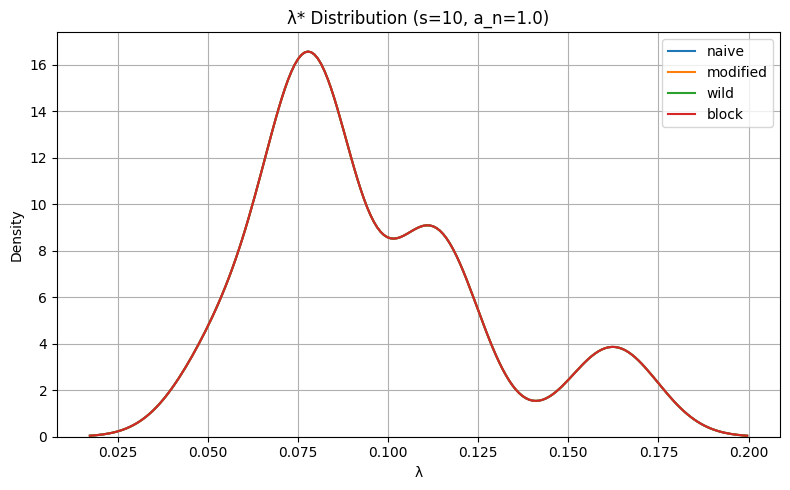

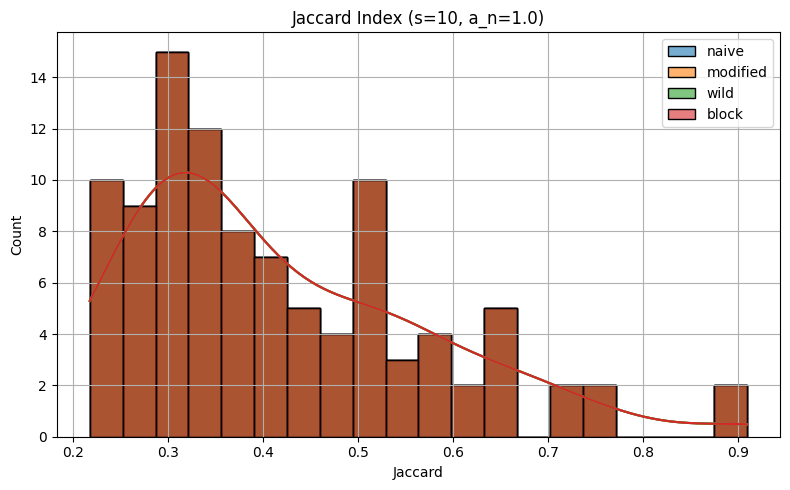

KeyError: 'beta_star'

<Figure size 800x500 with 0 Axes>

In [7]:
# Example: visualize results for s=10, a=1.0
res = results_case1["s10_a1.0"]
plot_lambda_distribution(res, "(s=10, a_n=1.0)")
plot_jaccard(res, "(s=10, a_n=1.0)")
plot_beta_distributions(res, j_list=[0, 1, 50], title_suffix="(s=10, a_n=1.0)")  # strong, weak, noise
